Carregando os dados e separando df's de treino e de teste.

In [6]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "dengue_pipeline").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

from dengue_pipeline import DengueDataCleaner
from dengue_pipeline.models import GradientBoostingDiseaseClassifier
from dengue_pipeline.paths import MODELS_DIR, MODEL_FIGURES_DIR, ML_PREPROCESS_PATH

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def salvar_modelo(modelo, nome_arquivo):
    caminho = MODELS_DIR / nome_arquivo
    joblib.dump(modelo, caminho)
    print(f"Modelo salvo em: {caminho}")
    return caminho

def plotar_importancias(importancias, titulo, nome_arquivo, top_n=30):
    dados = importancias.sort_values(ascending=False).head(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(dados.index, dados.values, color="#2563eb", alpha=0.9)
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Importância")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.22)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    caminho = MODEL_FIGURES_DIR / nome_arquivo
    fig.savefig(caminho, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Gráfico salvo em: {caminho}")

cleaner = DengueDataCleaner()
df = cleaner.transformar_ml()

# Salva os encoders ajustados (ocupação e UF) + a mediana de days_to_notification
# para a API reproduzir o mesmo pré-processamento na hora da predição.
joblib.dump(
    {
        "occupation_encoder": cleaner.occupation_encoder,
        "residence_state_encoder": cleaner.residence_state_encoder,
        "days_to_notification_median": cleaner.days_to_notification_median,
    },
    ML_PREPROCESS_PATH,
)
print(f"Pré-processamento salvo em: {ML_PREPROCESS_PATH}")

df_train = df[(df["notification_year"].isin([2017, 2018])) | ((df["notification_year"] == 2019) & (df["notification_month"] <= 5))].copy()
df_test = df[(df["notification_year"] == 2019) & (df["notification_month"] >= 6)].copy()

print("Treino:", df_train.shape)
print("Teste:", df_test.shape)

print("Proporção treino:", (len(df_train) / len(df))*100)
print("Proporção teste:", (len(df_test) / len(df))*100)

df.columns

Pré-processamento salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\ml_preprocess.joblib
Treino: (2345627, 111)
Teste: (528608, 111)
Proporção treino: 81.60874110850365
Proporção teste: 18.391258891496346


Index(['age_years', 'education_level', 'occupation_code', 'residence_state',
       'residence_municipality', 'residence_health_region',
       'notification_year', 'notification_month', 'notif_municipality',
       'notif_health_region',
       ...
       'arthritis_and_joint_pain', 'arthritis_and_petechiae',
       'arthritis_and_retro_orbital_pain', 'joint_pain_and_petechiae',
       'joint_pain_and_retro_orbital_pain', 'petechiae_and_retro_orbital_pain',
       'number_of_symptoms', 'number_of_important_symptoms', 'pregnancy',
       'pregnancy_informed'],
      dtype='str', length=111)

Definindo o target e eliminando colunas que não são apropriadas para o modelo

In [7]:
target = "final_classification"

y_train = df_train[target]
y_test = df_test[target]

cols_remove = ['final_classification']

X_train = df_train.drop(columns = cols_remove)
X_test = df_test.drop(columns=cols_remove)

X_train = X_train.select_dtypes(include=["number"])
X_test = X_test[X_train.columns]

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [8]:
administrative_features = [
    "notification_year",
    "notification_month",
    "symptom_epi_year",
    "notif_municipality",
    "notif_health_region",
    "health_facility",
]

X_train = X_train.drop(columns=administrative_features, errors="ignore")
X_test = X_test.drop(columns=administrative_features, errors="ignore")

Implementação de Regressão Logistica 

              precision    recall  f1-score   support

         0.0       0.49      0.81      0.61    218981
         1.0       0.75      0.42      0.53    309627

    accuracy                           0.58    528608
   macro avg       0.62      0.61      0.57    528608
weighted avg       0.64      0.58      0.57    528608

[[176599  42382]
 [181128 128499]]
Modelo salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\logistic_regression.joblib


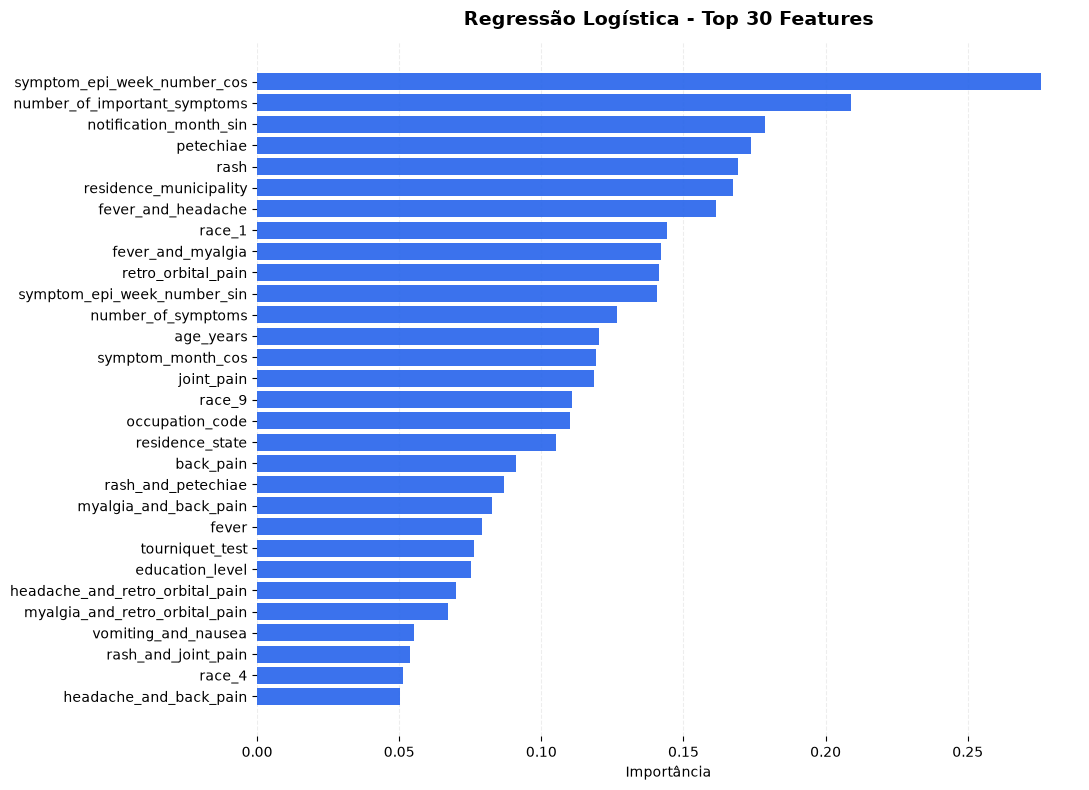

Gráfico salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\reports\figures\modeling\logistic_regression_feature_importance.png


In [9]:
#Regressao Logistica - testando...
from sklearn.linear_model import LogisticRegression

modelo_logistic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_logistic.fit(X_train, y_train)

y_pred_logistic = modelo_logistic.predict(X_test)

print(classification_report(y_test, y_pred_logistic))
print(confusion_matrix(y_test, y_pred_logistic))

salvar_modelo(modelo_logistic, "logistic_regression.joblib")
importancias_logistic = pd.Series(
    modelo_logistic.named_steps["classifier"].coef_[0],
    index=X_train.columns,
).abs().sort_values(ascending=False)
plotar_importancias(
    importancias_logistic,
    "Regressão Logística - Top 30 Features",
    "logistic_regression_feature_importance.png",
)

Implementação de XGBoost

Optuna usando amostra estratificada de 200,000 registros.


  0%|          | 0/200 [00:00<?, ?it/s]c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:49:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:49:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:49:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xg

Melhor average_precision: 0.8754
Melhores parâmetros: {'n_estimators': 500, 'learning_rate': 0.05307299610158423, 'max_depth': 8, 'subsample': 0.982725260345373, 'colsample_bytree': 0.9940043327749457, 'reg_alpha': 9.839064036723272e-07, 'reg_lambda': 0.0001901761880334503, 'min_child_weight': 3}


c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.53      0.86      0.66    218981
         1.0       0.83      0.46      0.59    309627

    accuracy                           0.63    528608
   macro avg       0.68      0.66      0.62    528608
weighted avg       0.70      0.63      0.62    528608

[[189082  29899]
 [168009 141618]]
 threshold  accuracy  precision  recall     f1
    0.0300    0.6296     0.6140  0.9901 0.7580
    0.0500    0.6627     0.6409  0.9645 0.7701
    0.0700    0.6829     0.6619  0.9377 0.7760
    0.1000    0.6989     0.6838  0.9040 0.7786
    0.1500    0.7011     0.7071  0.8360 0.7662
    0.2000    0.6953     0.7251  0.7729 0.7482
    0.2500    0.6889     0.7415  0.7199 0.7305
    0.3000    0.6808     0.7571  0.6700 0.7109
    0.4000    0.6580     0.7907  0.5660 0.6598
    0.5000    0.6256     0.8257  0.4574 0.5887
    0.6000    0.5885     0.8622  0.3540 0.5019
    0.7000    0.5485     0.8978  0.2585 0.4015
    0.8000    0.5119     0.

,threshold,accuracy,precision,recall,f1
0,0.03,0.629640,0.614013,0.990137,0.757980
1,0.05,0.662686,0.640925,0.964451,0.770089
2,0.07,0.682930,0.661877,0.937725,0.776016
3,0.10,0.698930,0.683811,0.904007,0.778641
4,0.15,0.701107,0.707114,0.835980,0.766166
5,0.20,0.695334,0.725096,0.772882,0.748227
6,0.25,0.688904,0.741478,0.719873,0.730516
7,0.30,0.680799,0.757075,0.670048,0.710908
8,0.40,0.658036,0.790678,0.566036,0.659759
9,0.50,0.625605,0.825679,0.457383,0.588672


Modelo salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\xgboost.joblib


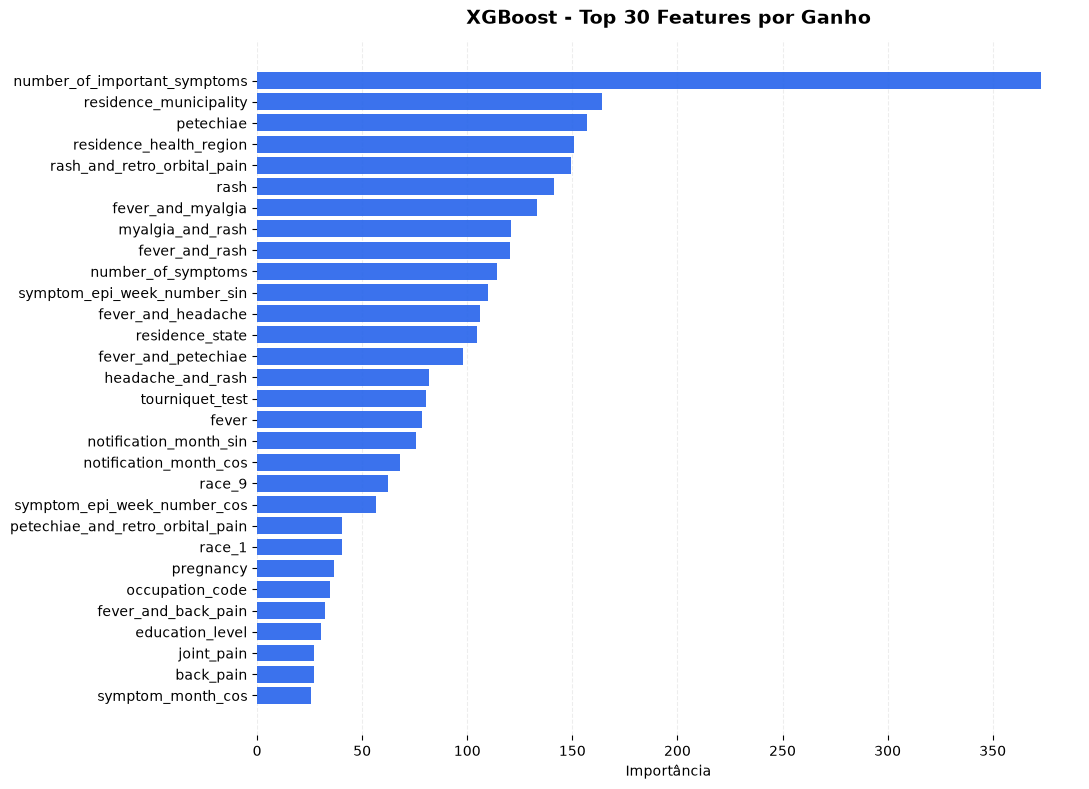

Gráfico salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\reports\figures\modeling\xgboost_feature_importance.png


In [10]:
# Teste da classe adaptada usando XGBoost.
# O XGBoost trata valores ausentes nativamente.
modelo_xgb = GradientBoostingDiseaseClassifier(
    model="xgb",
    fast_train=False,
    device="cuda"
)

modelo_xgb.fit(
    X_train,
    y_train,
    n_trials=200,
    tuning_sample_size=200_000,
)
y_pred_xgb = modelo_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

resultados_limiares_xgb = modelo_xgb.evaluate(
    X_test,
    y_test,
    thresholds=[0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80],
)
display(resultados_limiares_xgb)

salvar_modelo(modelo_xgb, "xgboost.joblib")
importancias_xgb = modelo_xgb.feature_importance(importance_type="gain")
plotar_importancias(
    importancias_xgb,
    "XGBoost - Top 30 Features por Ganho",
    "xgboost_feature_importance.png",
)

Optuna usando amostra estratificada de 200,000 registros.


Best trial: 173. Best value: 0.879085: 100%|██████████| 200/200 [17:20<00:00,  5.20s/it]


Melhor average_precision: 0.8791
Melhores parâmetros: {'n_estimators': 400, 'learning_rate': 0.08520563449879102, 'max_depth': 8, 'subsample': 0.8350289381492695, 'colsample_bytree': 0.7127202858389637, 'reg_alpha': 0.43881170853798995, 'reg_lambda': 0.00011704622282468992, 'num_leaves': 149, 'min_child_samples': 31}
              precision    recall  f1-score   support

         0.0       0.53      0.87      0.66    218981
         1.0       0.84      0.46      0.59    309627

    accuracy                           0.63    528608
   macro avg       0.68      0.67      0.63    528608
weighted avg       0.71      0.63      0.62    528608

[[190909  28072]
 [166932 142695]]
 threshold  accuracy  precision  recall     f1
    0.0300    0.6275     0.6124  0.9918 0.7572
    0.0500    0.6637     0.6407  0.9693 0.7715
    0.0700    0.6858     0.6630  0.9427 0.7785
    0.1000    0.7015     0.6858  0.9049 0.7803
    0.1500    0.7057     0.7106  0.8394 0.7696
    0.2000    0.7017     0.7305  0.77

,threshold,accuracy,precision,recall,f1
0,0.03,0.627459,0.612368,0.991793,0.757209
1,0.05,0.663671,0.640743,0.969257,0.771484
2,0.07,0.685797,0.663028,0.942679,0.778502
3,0.10,0.701452,0.685795,0.904895,0.780256
4,0.15,0.705703,0.710621,0.839371,0.769649
5,0.20,0.701728,0.730515,0.777652,0.753347
6,0.25,0.695939,0.748468,0.724307,0.736189
7,0.30,0.688764,0.766159,0.674515,0.717422
8,0.40,0.664279,0.801080,0.567848,0.664595
9,0.50,0.631099,0.835612,0.460861,0.594075


Modelo salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\lightgbm.joblib


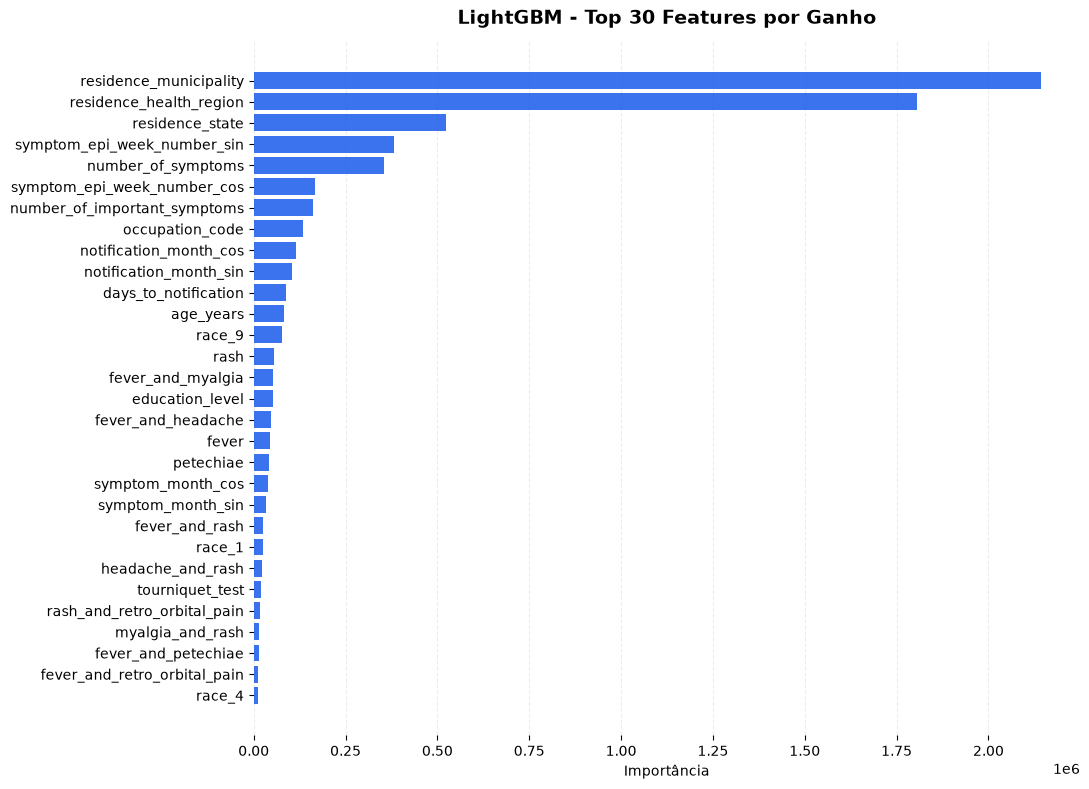

Gráfico salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\reports\figures\modeling\lightgbm_feature_importance.png


In [11]:
# Teste da classe adaptada usando LightGBM.
# O LightGBM trata valores ausentes nativamente.
modelo_lgb = GradientBoostingDiseaseClassifier(
    model="lgbm",
    fast_train=False,
    device="cpu"
)

modelo_lgb.fit(
    X_train,
    y_train,
    n_trials=200,
    tuning_sample_size=200_000,
)
y_pred_lgb = modelo_lgb.predict(X_test)

print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))

resultados_limiares_lgb = modelo_lgb.evaluate(
    X_test,
    y_test,
    thresholds=[0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80],
)
display(resultados_limiares_lgb)

salvar_modelo(modelo_lgb, "lightgbm.joblib")
importancias_lgb = modelo_lgb.feature_importance(importance_type="gain")
plotar_importancias(
    importancias_lgb,
    "LightGBM - Top 30 Features por Ganho",
    "lightgbm_feature_importance.png",
)

Implementação de Arvore de Decisao

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_decision_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_decision_tree.fit(X_train, y_train)

y_pred_decision_tree = modelo_decision_tree.predict(X_test)

print(classification_report(y_test, y_pred_decision_tree))
print(confusion_matrix(y_test, y_pred_decision_tree))

salvar_modelo(modelo_decision_tree, "decision_tree.joblib")
importancias_decision_tree = pd.Series(
    modelo_decision_tree.named_steps["classifier"].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)
plotar_importancias(
    importancias_decision_tree,
    "Árvore de Decisão - Top 30 Features",
    "decision_tree_feature_importance.png",
)